# 06 — Model Training

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 2.0

---

## Objectives

Train and tune predictive models using time-series cross-validation:

1. **Data preparation** — load feature matrix, reconstruct train/test split, impute NaN
2. **LASSO baseline** — regularised linear regression, interpretable benchmark
3. **XGBoost** — gradient boosted trees with `TimeSeriesSplit` CV and early stopping
4. **LightGBM** — fast gradient boosting, compared against XGBoost on same CV folds
5. **Hyperparameter tuning** — `RandomizedSearchCV` with time-series CV (no leakage)
6. **SHAP explainability** — global and local feature attribution for best model
7. **Model comparison** — CV metrics table, out-of-sample test performance
8. **Model persistence** — save best models and metadata to `models/`

**Target:** `fwd_return_1d` (next-day log return) — primary  
**Also evaluated:** `fwd_return_5d`, `fwd_return_10d`  
**Metric:** RMSE (primary), MAE, R², Directional Accuracy


In [1]:
import os, sys, warnings, pickle, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Gradient boosting ──────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.float_format', '{:.5f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIGS   = ROOT / 'reports' / 'figures'
MODELS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
})

# ── Constants ──────────────────────────────────────────────────────────────────
TRAIN_CUTOFF    = '2022-12-31'
PRIMARY_TARGET  = 'fwd_return_1d'
TARGET_COLS     = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_10d']
N_CV_SPLITS     = 5
RANDOM_STATE    = 42
N_ITER_SEARCH   = 30        # RandomizedSearchCV iterations

print('✓ Imports complete')
print(f'  XGBoost  : {xgb.__version__}')
print(f'  LightGBM : {lgb.__version__}')
print(f'  SHAP     : {shap.__version__}')
print(f'  Target   : {PRIMARY_TARGET}')
print(f'  CV folds : {N_CV_SPLITS} (TimeSeriesSplit)')

✓ Imports complete
  XGBoost  : 3.2.0
  LightGBM : 4.6.0
  SHAP     : 0.51.0
  Target   : fwd_return_1d
  CV folds : 5 (TimeSeriesSplit)


---
## Section 1 — Load Data & Reconstruct Split

In [2]:
# ── Load feature matrix ────────────────────────────────────────────────────────
feature_df = pd.read_parquet(PROC / 'model_features.parquet')
feature_df['date'] = pd.to_datetime(feature_df['date'])

# ── Load feature metadata (selected features + importance) ────────────────────
meta = pd.read_parquet(PROC / 'feature_metadata.parquet')
SELECTED_FEATURES = meta[meta['selected']]['feature'].tolist()

# ── Load scaler (fitted on train in Phase 5) ──────────────────────────────────
with open(PROC / 'scaler.pkl', 'rb') as f:
    scaler_obj = pickle.load(f)
scaler = scaler_obj['scaler']

print(f'Feature matrix   : {feature_df.shape[0]:,} rows x {feature_df.shape[1]} cols')
print(f'Selected features: {len(SELECTED_FEATURES)}')
print(f'Date range       : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')

# ── Train / test split ────────────────────────────────────────────────────────
train_df = feature_df[feature_df['date'] <= TRAIN_CUTOFF].copy()
test_df  = feature_df[feature_df['date'] >  TRAIN_CUTOFF].copy()

# ── Build X / y matrices ──────────────────────────────────────────────────────
# Impute NaN with column median (computed on train only)
train_medians = train_df[SELECTED_FEATURES].median()

X_train = train_df[SELECTED_FEATURES].fillna(train_medians)
X_test  = test_df[SELECTED_FEATURES].fillna(train_medians)
y_train = train_df[PRIMARY_TARGET]
y_test  = test_df[PRIMARY_TARGET]

# Scaled versions (for LASSO)
X_train_sc = pd.DataFrame(
    scaler.transform(X_train), columns=SELECTED_FEATURES, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test), columns=SELECTED_FEATURES, index=X_test.index
)

print(f'\nX_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'Train   : {train_df["date"].min().date()} -> {train_df["date"].max().date()}')
print(f'Test    : {test_df["date"].min().date()}  -> {test_df["date"].max().date()}')

Feature matrix   : 2,763 rows x 95 cols
Selected features: 52
Date range       : 2015-01-05 -> 2025-12-29

X_train : (2013, 52)  |  y_train : (2013,)
X_test  : (750, 52)   |  y_test  : (750,)
Train   : 2015-01-05 -> 2022-12-30
Test    : 2023-01-03  -> 2025-12-29


---
## Section 2 — Evaluation Helpers

In [3]:
def evaluate(y_true, y_pred, label=''):
    """Return dict of regression + directional accuracy metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Directional accuracy: did we get the sign right?
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    # Information coefficient (rank correlation)
    ic = pd.Series(y_pred).corr(pd.Series(y_true.values), method='spearman')
    metrics = {'RMSE': rmse, 'MAE': mae, 'R2': r2,
               'Dir_Acc': dir_acc, 'IC': ic}
    if label:
        print(f'  {label:<25} RMSE={rmse:.5f}  MAE={mae:.5f}  R²={r2:.4f}  DirAcc={dir_acc:.3f}  IC={ic:.3f}')
    return metrics


def cv_score(model, X, y, n_splits=N_CV_SPLITS, scaled=False):
    """TimeSeriesSplit CV — returns mean metrics across folds."""
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    folds  = []
    X_use  = X_train_sc if scaled else X
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_use)):
        X_tr, X_val = X_use.iloc[tr_idx], X_use.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],     y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        folds.append(evaluate(y_val, preds))
    mean_metrics = {k: np.mean([f[k] for f in folds]) for k in folds[0]}
    return mean_metrics


# Results tracker
results = {}
print('✓ Evaluation helpers defined')

✓ Evaluation helpers defined


---
## Section 3 — LASSO Baseline

In [4]:
print('Training LASSO baseline...')

# ── LassoCV to find optimal alpha ─────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
lasso_cv = LassoCV(
    alphas=np.logspace(-6, 1, 50),
    cv=tscv,
    max_iter=10000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lasso_cv.fit(X_train_sc, y_train)
best_alpha = lasso_cv.alpha_
print(f'  Best alpha (LassoCV): {best_alpha:.6f}')

# ── Fit final LASSO ────────────────────────────────────────────────────────────
lasso = Lasso(alpha=best_alpha, max_iter=10000, random_state=RANDOM_STATE)
lasso.fit(X_train_sc, y_train)

n_nonzero = np.sum(lasso.coef_ != 0)
print(f'  Non-zero coefficients: {n_nonzero} / {len(SELECTED_FEATURES)}')

# ── Evaluate ───────────────────────────────────────────────────────────────────
lasso_train_pred = lasso.predict(X_train_sc)
lasso_test_pred  = lasso.predict(X_test_sc)

print('\nLASSO results:')
results['LASSO_train'] = evaluate(y_train, lasso_train_pred, 'LASSO (train)')
results['LASSO_test']  = evaluate(y_test,  lasso_test_pred,  'LASSO (test) ')

# ── Top LASSO coefficients ─────────────────────────────────────────────────────
lasso_coef = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'coef': lasso.coef_
}).query('coef != 0').reindex(
    pd.Series(lasso.coef_).abs().sort_values(ascending=False).index
).dropna().sort_values('coef', key=abs, ascending=False)

print(f'\nTop 10 LASSO coefficients:')
print(lasso_coef.head(10).to_string(index=False))

# Save
with open(MODELS / 'lasso.pkl', 'wb') as f:
    pickle.dump({'model': lasso, 'alpha': best_alpha, 'features': SELECTED_FEATURES}, f)
print('\n✓ LASSO saved to models/lasso.pkl')

Training LASSO baseline...
  Best alpha (LassoCV): 0.000518
  Non-zero coefficients: 10 / 52

LASSO results:
  LASSO (train)             RMSE=0.01121  MAE=0.00739  R²=0.0921  DirAcc=0.562  IC=0.166
  LASSO (test)              RMSE=0.00946  MAE=0.00652  R²=0.0328  DirAcc=0.564  IC=0.179

Top 10 LASSO coefficients:
          feature     coef
         mean_car  0.00197
       log_return -0.00114
     return_lag5d -0.00102
   monetary_x_vix  0.00055
     return_lag3d -0.00050
    return_lag21d -0.00044
sent_x_vix_regime  0.00036
     n_sig_events -0.00018
    vix_change_1d  0.00007
    cum_return_5d -0.00005

✓ LASSO saved to models/lasso.pkl


---
## Section 4 — XGBoost with TimeSeriesSplit CV

In [5]:
print('XGBoost hyperparameter search...')

xgb_param_dist = {
    'n_estimators':      [200, 400, 600, 800],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'reg_alpha':         [0, 0.01, 0.1],
    'reg_lambda':        [1, 1.5, 2],
}

xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
xgb_search.fit(X_train, y_train)

best_xgb_params = xgb_search.best_params_
print(f'\nBest XGBoost params: {best_xgb_params}')
print(f'Best CV RMSE       : {-xgb_search.best_score_:.5f}')

XGBoost hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE       : 0.01163


In [6]:
# ── Fit final XGBoost on full train set ───────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    **best_xgb_params,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred  = xgb_model.predict(X_test)

print('XGBoost results:')
results['XGB_train'] = evaluate(y_train, xgb_train_pred, 'XGBoost (train)')
results['XGB_test']  = evaluate(y_test,  xgb_test_pred,  'XGBoost (test) ')

# Save
xgb_model.save_model(str(MODELS / 'xgboost.json'))
with open(MODELS / 'xgboost_params.json', 'w') as f:
    json.dump(best_xgb_params, f, indent=2)
print('\n✓ XGBoost saved to models/xgboost.json')

XGBoost results:
  XGBoost (train)           RMSE=0.00786  MAE=0.00557  R²=0.5538  DirAcc=0.753  IC=0.758
  XGBoost (test)            RMSE=0.00948  MAE=0.00666  R²=0.0298  DirAcc=0.524  IC=0.121

✓ XGBoost saved to models/xgboost.json


---
## Section 5 — LightGBM with TimeSeriesSplit CV

In [7]:
print('LightGBM hyperparameter search...')

lgb_param_dist = {
    'n_estimators':      [200, 400, 600, 800],
    'max_depth':         [3, 4, 5, 6, -1],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'num_leaves':        [15, 31, 63, 127],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha':         [0, 0.01, 0.1],
    'reg_lambda':        [0, 0.1, 1.0],
}

lgb_base = lgb.LGBMRegressor(
    objective='regression',
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
lgb_search = RandomizedSearchCV(
    lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
lgb_search.fit(X_train, y_train)

best_lgb_params = lgb_search.best_params_
print(f'\nBest LightGBM params: {best_lgb_params}')
print(f'Best CV RMSE        : {-lgb_search.best_score_:.5f}')

LightGBM hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE        : 0.01152


In [8]:
# ── Fit final LightGBM on full train set ──────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    **best_lgb_params,
    objective='regression',
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)
lgb_model.fit(X_train, y_train)

lgb_train_pred = lgb_model.predict(X_train)
lgb_test_pred  = lgb_model.predict(X_test)

print('LightGBM results:')
results['LGB_train'] = evaluate(y_train, lgb_train_pred, 'LightGBM (train)')
results['LGB_test']  = evaluate(y_test,  lgb_test_pred,  'LightGBM (test) ')

# Save
lgb_model.booster_.save_model(str(MODELS / 'lightgbm.txt'))
with open(MODELS / 'lightgbm_params.json', 'w') as f:
    json.dump(best_lgb_params, f, indent=2)
print('\n✓ LightGBM saved to models/lightgbm.txt')

LightGBM results:
  LightGBM (train)          RMSE=0.01038  MAE=0.00697  R²=0.2212  DirAcc=0.610  IC=0.389
  LightGBM (test)           RMSE=0.00947  MAE=0.00661  R²=0.0309  DirAcc=0.551  IC=0.133

✓ LightGBM saved to models/lightgbm.txt


---
## Section 6 — Model Comparison

In [9]:
# ── Build comparison table ────────────────────────────────────────────────────
rows = []
for key, metrics in results.items():
    model_name, split = key.rsplit('_', 1)
    rows.append({'Model': model_name, 'Split': split, **metrics})

comp_df = pd.DataFrame(rows)
test_comp = comp_df[comp_df['Split'] == 'test'].set_index('Model')

print('=' * 75)
print('MODEL COMPARISON — OUT-OF-SAMPLE TEST PERFORMANCE')
print('=' * 75)
print(test_comp[['RMSE','MAE','R2','Dir_Acc','IC']].round(5).to_string())
print('\n  Dir_Acc = Directional Accuracy (sign correct %)')
print('  IC      = Information Coefficient (Spearman rank correlation)')

# ── Select best model ──────────────────────────────────────────────────────────
best_model_name = test_comp['RMSE'].idxmin()
print(f'\n→ Best model by test RMSE: {best_model_name}')

# Map to model object
model_map = {'LASSO': lasso, 'XGB': xgb_model, 'LGB': lgb_model}
pred_map  = {'LASSO': lasso_test_pred, 'XGB': xgb_test_pred, 'LGB': lgb_test_pred}
best_model = model_map[best_model_name]
best_pred  = pred_map[best_model_name]

# Save comparison table
comp_df.to_parquet(PROC / 'model_comparison.parquet', index=False)
print('✓ model_comparison.parquet saved')

MODEL COMPARISON — OUT-OF-SAMPLE TEST PERFORMANCE
         RMSE     MAE      R2  Dir_Acc      IC
Model                                         
LASSO 0.00946 0.00652 0.03276  0.56400 0.17861
XGB   0.00948 0.00666 0.02976  0.52400 0.12114
LGB   0.00947 0.00661 0.03090  0.55067 0.13293

  Dir_Acc = Directional Accuracy (sign correct %)
  IC      = Information Coefficient (Spearman rank correlation)

→ Best model by test RMSE: LASSO
✓ model_comparison.parquet saved


---
## Section 7 — SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, providing both global importance and local (per-prediction) explanations.

In [10]:
print(f'Computing SHAP values for {best_model_name}...')

# Use best tree-based model (XGB or LGB) for TreeExplainer
# Fall back to KernelExplainer for LASSO
shap_X = X_test if best_model_name != 'LASSO' else X_test_sc

if best_model_name in ('XGB', 'LGB'):
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(shap_X)
else:
    # LASSO — use linear explainer
    explainer   = shap.LinearExplainer(best_model, X_train_sc)
    shap_values = explainer.shap_values(shap_X)

shap_df = pd.DataFrame(shap_values, columns=SELECTED_FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f'\nTop 15 features by mean |SHAP|:')
print(mean_abs_shap.head(15).round(6).to_string())
print(f'\n✓ SHAP values computed for {len(shap_X)} test observations')

Computing SHAP values for LASSO...

Top 15 features by mean |SHAP|:
mean_car               0.00112
log_return             0.00064
return_lag5d           0.00059
return_lag3d           0.00029
return_lag21d          0.00025
monetary_x_vix         0.00011
sent_x_vix_regime      0.00009
n_sig_events           0.00005
vix_change_1d          0.00003
cum_return_5d          0.00003
rsi_oversold           0.00000
volume_ratio           0.00000
n_high_impact_events   0.00000
total_events           0.00000
volatility_21d         0.00000

✓ SHAP values computed for 750 test observations


---
## Section 8 — Visualisations

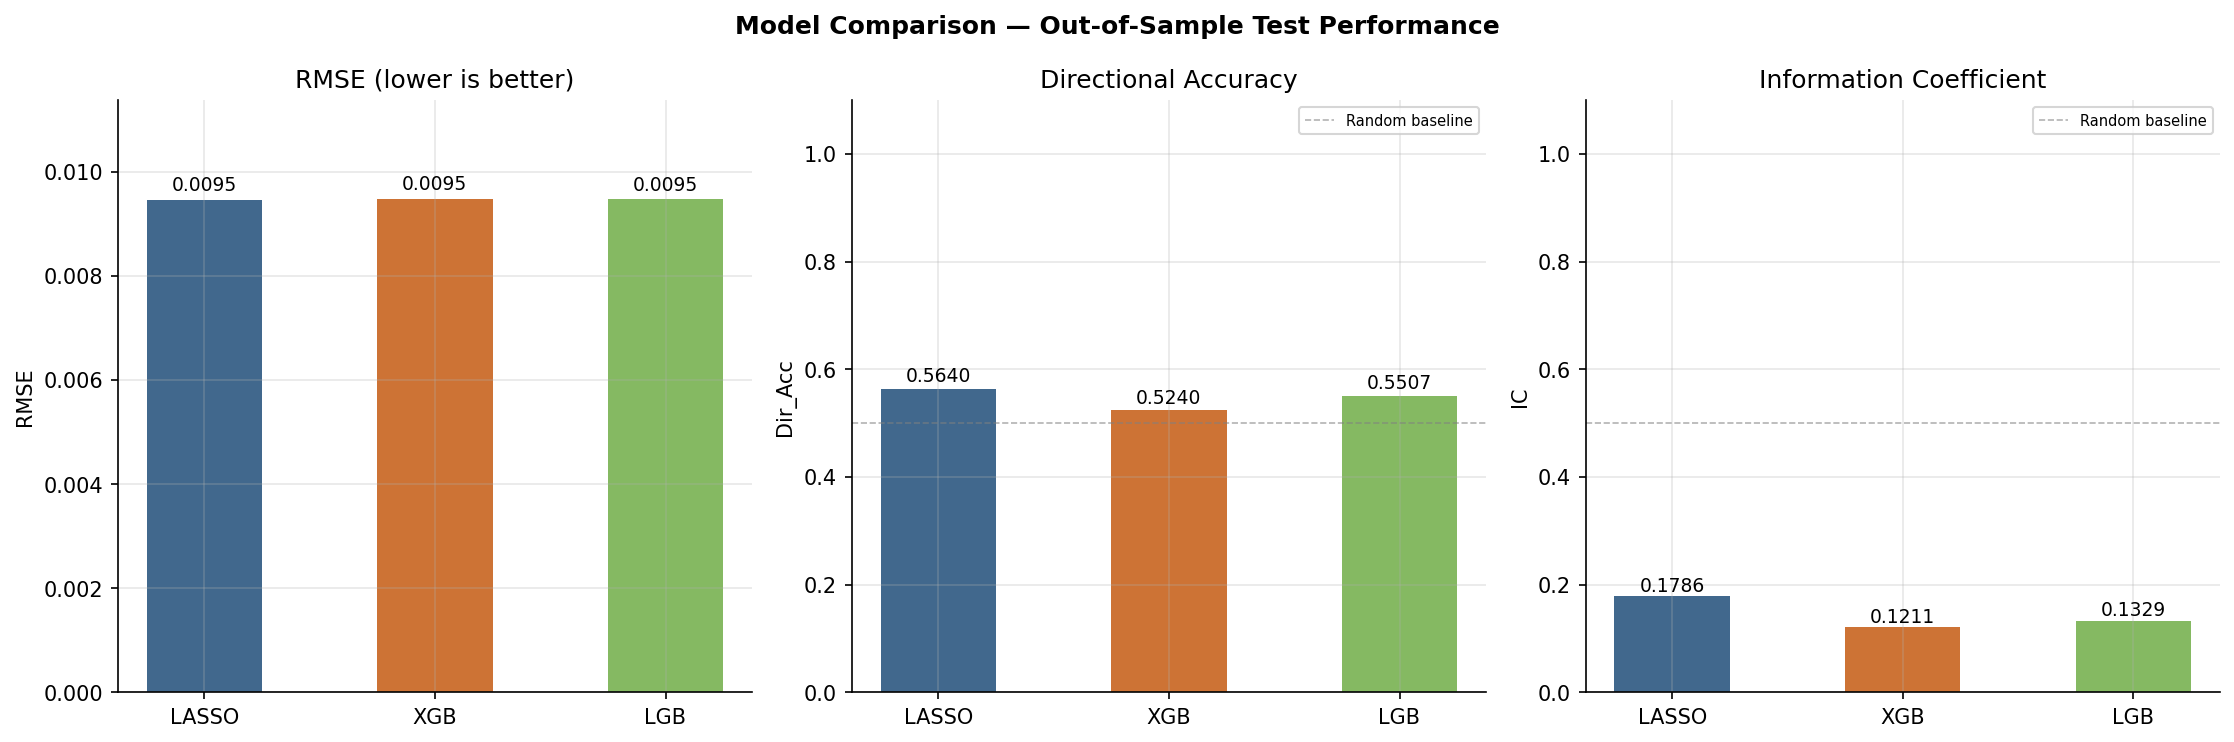

✓ Saved 06a_model_comparison.png


In [11]:
# ── Figure 06a: Model comparison bar chart ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models    = test_comp.index.tolist()
colours   = ['#1f4e79', '#c55a11', '#70ad47']

for ax, metric, title in zip(
    axes,
    ['RMSE', 'Dir_Acc', 'IC'],
    ['RMSE (lower is better)', 'Directional Accuracy', 'Information Coefficient']
):
    vals = test_comp[metric].values
    bars = ax.bar(models, vals, color=colours, alpha=0.85, width=0.5)
    ax.set_title(title)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    if metric == 'RMSE':
        ax.set_ylim(0, max(vals) * 1.2)
    else:
        ax.set_ylim(0, 1.1)
        ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.6,
                   label='Random baseline')
        ax.legend(fontsize=7)

plt.suptitle('Model Comparison — Out-of-Sample Test Performance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '06a_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 06a_model_comparison.png')

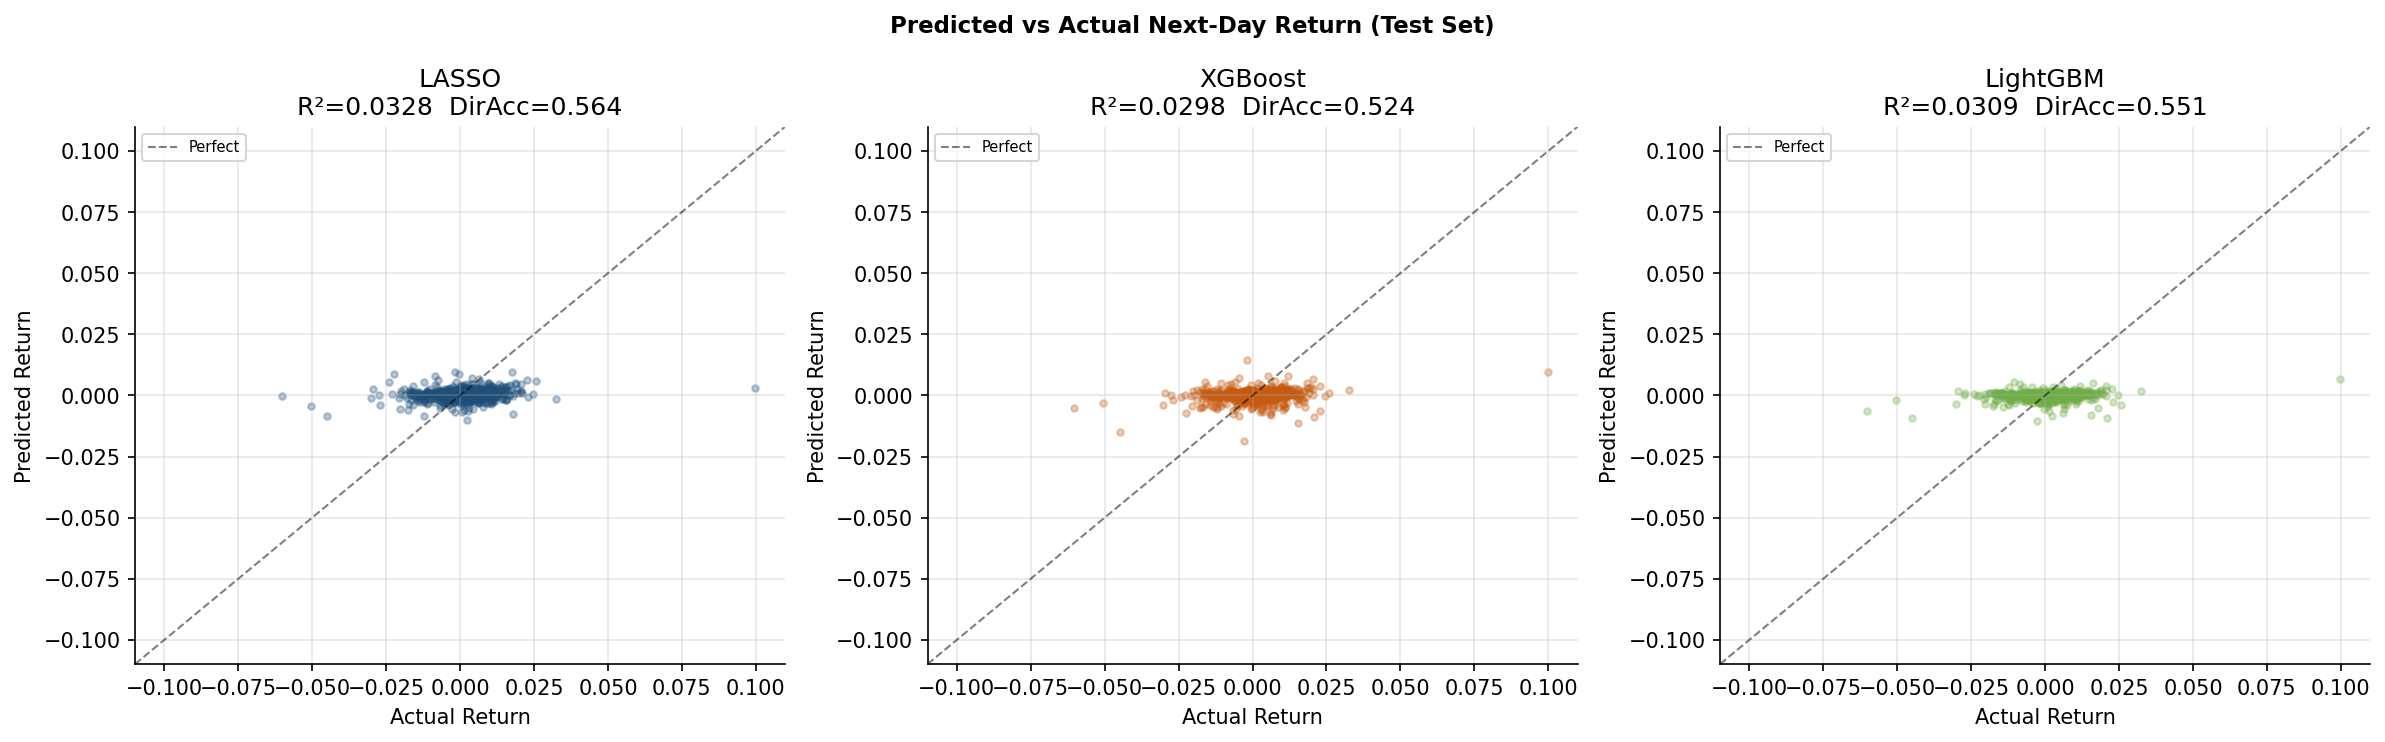

✓ Saved 06b_predicted_vs_actual.png


In [12]:
# ── Figure 06b: Predicted vs actual returns ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pred_items = [
    ('LASSO',    lasso_test_pred,  '#1f4e79', 'LASSO'),
    ('XGBoost',  xgb_test_pred,   '#c55a11', 'XGB'),
    ('LightGBM', lgb_test_pred,   '#70ad47', 'LGB'),
]

for ax, (name, preds, col, key) in zip(axes, pred_items):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color=col)
    lim = max(abs(y_test.min()), abs(y_test.max())) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='Perfect')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual Return')
    ax.set_ylabel('Predicted Return')
    r2 = results[f'{key}_test']['R2']
    da = results[f'{key}_test']['Dir_Acc']
    ax.set_title(f'{name}\nR²={r2:.4f}  DirAcc={da:.3f}')
    ax.legend(fontsize=7)

plt.suptitle('Predicted vs Actual Next-Day Return (Test Set)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '06b_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 06b_predicted_vs_actual.png')


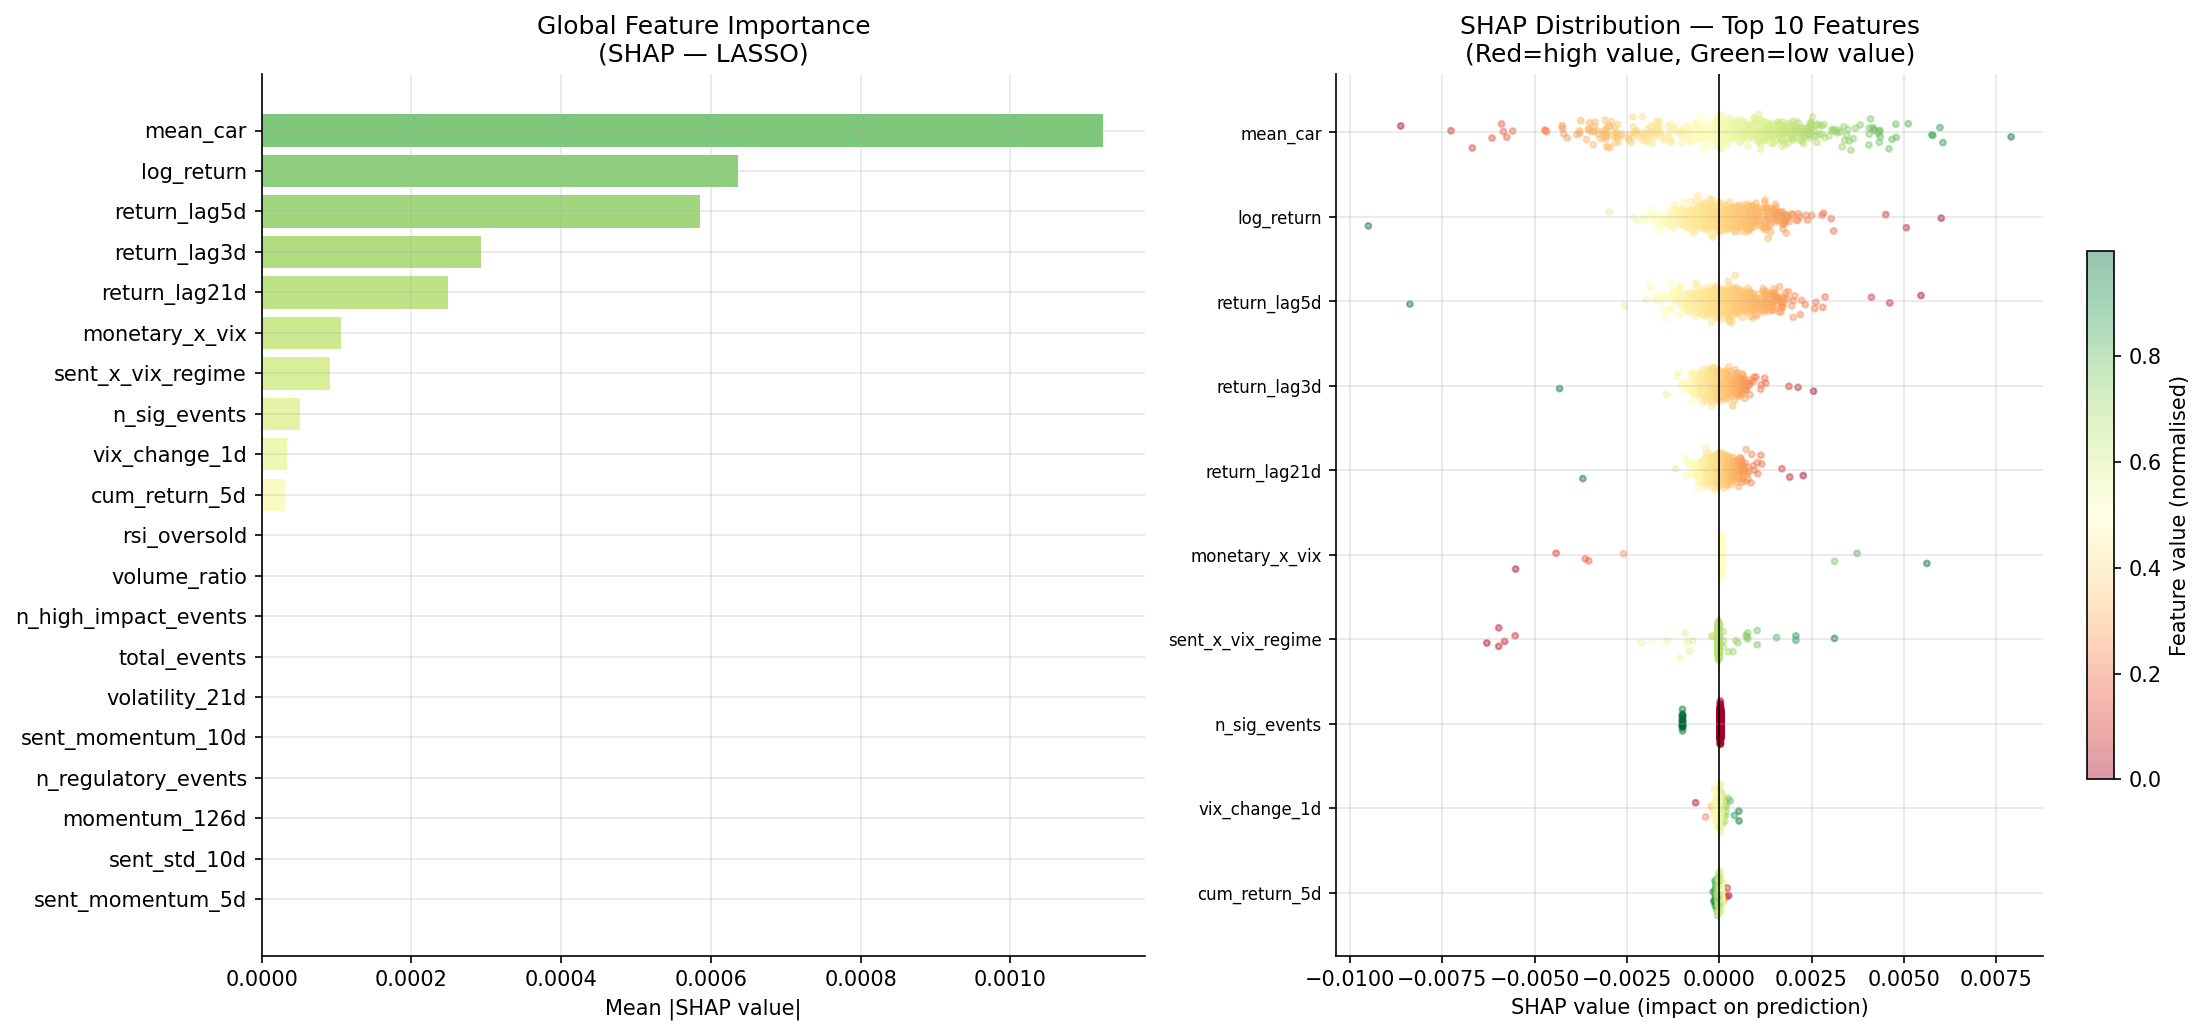

✓ Saved 06c_shap_summary.png


In [13]:
# ── Figure 06c: SHAP summary plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel 1: mean |SHAP| bar chart (top 20)
ax = axes[0]
top20_shap = mean_abs_shap.head(20)
colours_shap = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top20_shap)))
ax.barh(top20_shap.index[::-1], top20_shap.values[::-1],
        color=colours_shap, alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Global Feature Importance\n(SHAP — {best_model_name})')

# Panel 2: SHAP beeswarm-style scatter for top 10 features
ax2 = axes[1]
top10_feats = mean_abs_shap.head(10).index.tolist()
for i, feat in enumerate(top10_feats[::-1]):
    feat_vals   = shap_X[feat].values
    shap_vals   = shap_df[feat].values
    # Normalise feature value for colour
    #feat_norm   = (feat_vals - feat_vals.min()) / (feat_vals.ptp() + 1e-9)
    feat_norm = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-9)

    jitter      = np.random.normal(0, 0.08, len(shap_vals))
    sc = ax2.scatter(shap_vals, np.full_like(shap_vals, i) + jitter,
                     c=feat_norm, cmap='RdYlGn', alpha=0.4, s=8)
ax2.set_yticks(range(len(top10_feats)))
ax2.set_yticklabels(top10_feats[::-1], fontsize=8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('SHAP value (impact on prediction)')
ax2.set_title('SHAP Distribution — Top 10 Features\n(Red=high value, Green=low value)')
plt.colorbar(sc, ax=ax2, label='Feature value (normalised)', shrink=0.6)

plt.tight_layout()
plt.savefig(FIGS / '06c_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 06c_shap_summary.png')

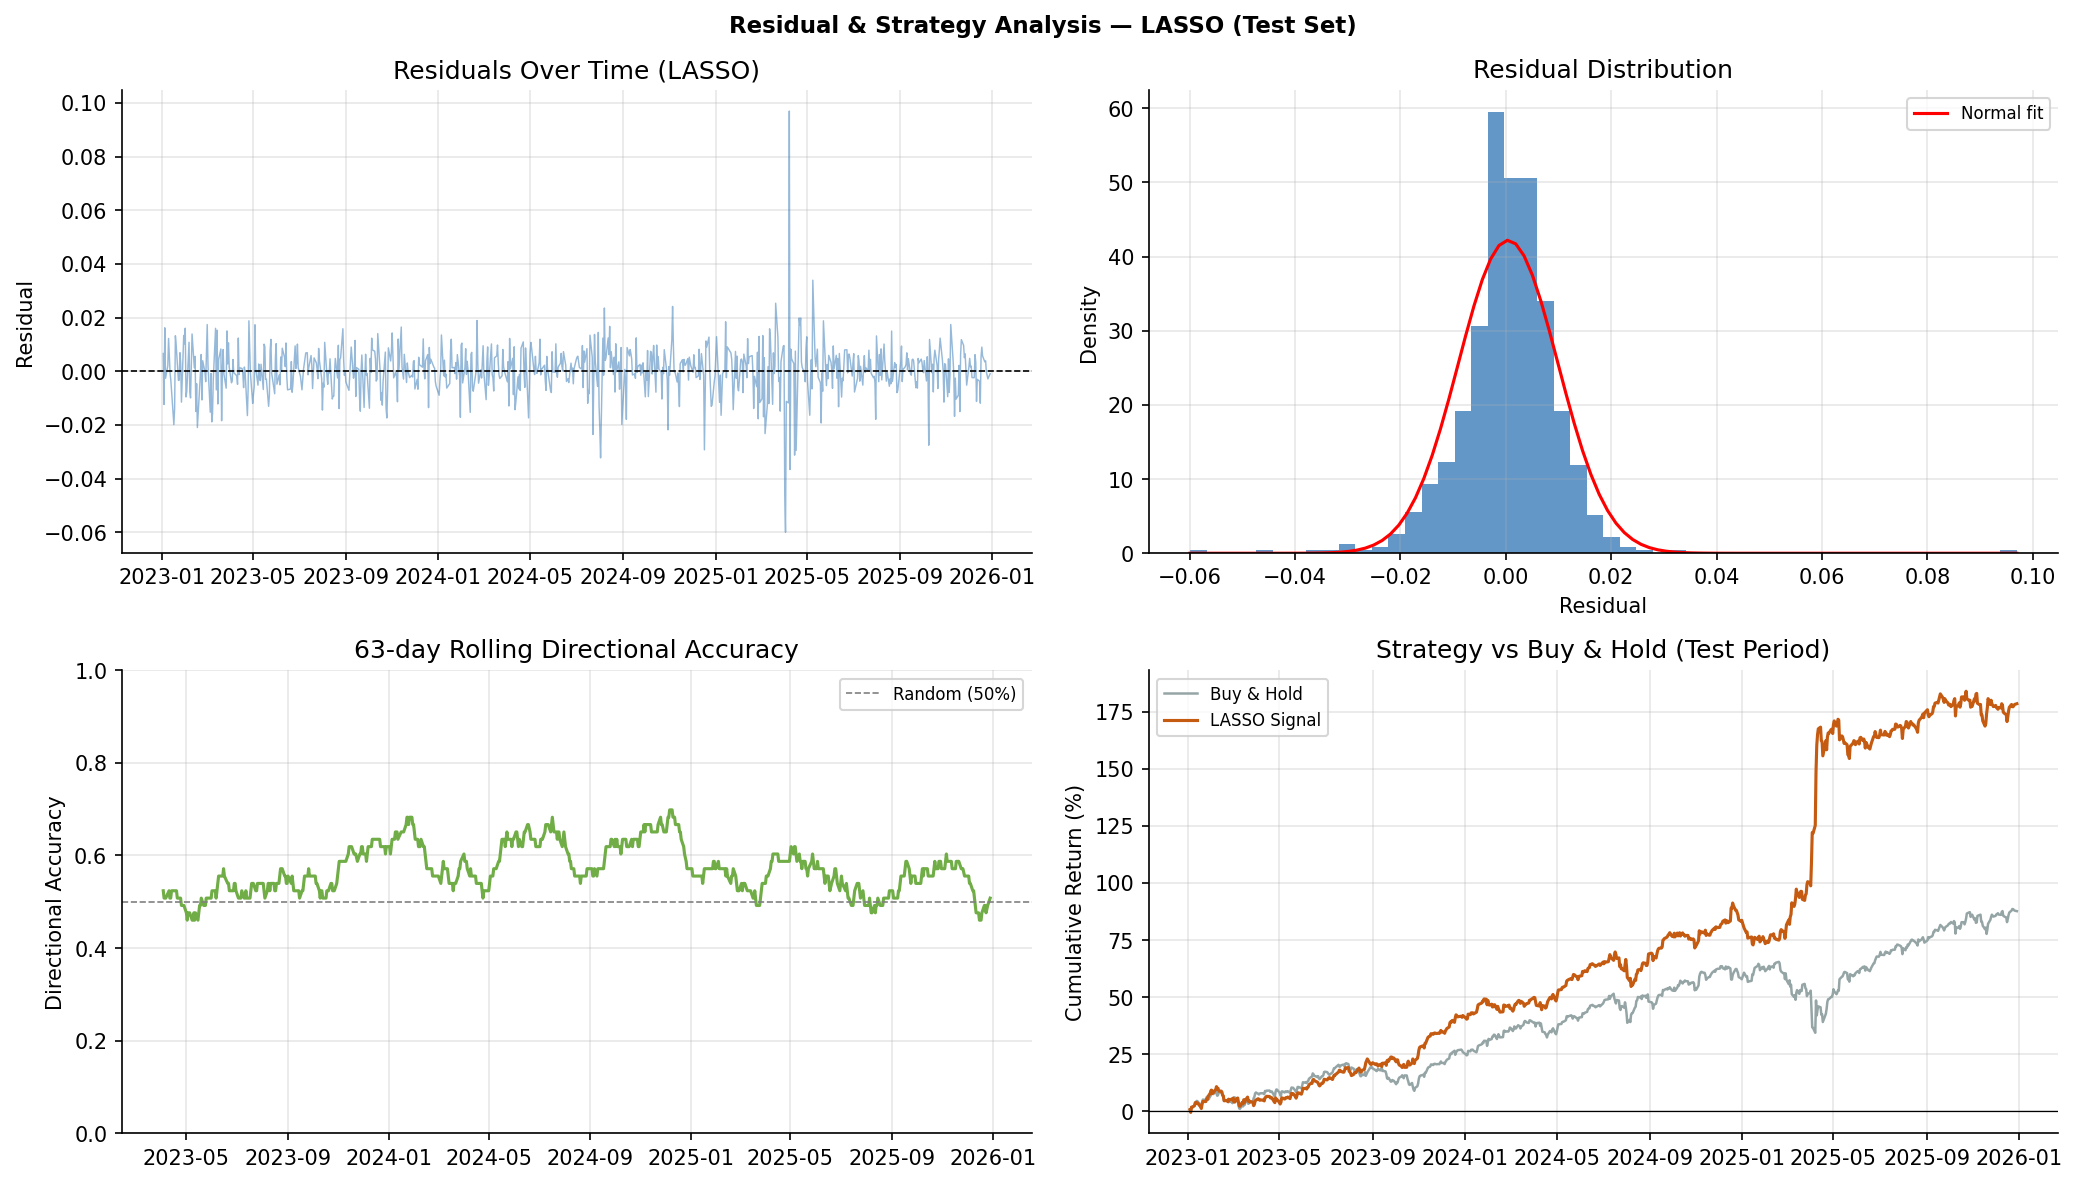

✓ Saved 06d_residual_analysis.png


In [14]:
# ── Figure 06d: Residual analysis for best model ──────────────────────────────
residuals = y_test.values - best_pred
test_dates = test_df['date'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: residuals over time
ax = axes[0, 0]
ax.plot(test_dates, residuals, alpha=0.5, linewidth=0.7, color='#2e75b6')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Residual')
ax.set_title(f'Residuals Over Time ({best_model_name})')

# Panel 2: residual distribution
ax2 = axes[0, 1]
ax2.hist(residuals, bins=50, color='#2e75b6', alpha=0.75, density=True)
from scipy.stats import norm
x_range = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_range, norm.pdf(x_range, residuals.mean(), residuals.std()),
         'r-', linewidth=1.5, label='Normal fit')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution')
ax2.legend(fontsize=8)

# Panel 3: rolling directional accuracy (63-day window)
ax3 = axes[1, 0]
dir_correct = (np.sign(y_test.values) == np.sign(best_pred)).astype(float)
rolling_da  = pd.Series(dir_correct, index=test_dates).rolling(63).mean()
ax3.plot(test_dates, rolling_da, color='#70ad47', linewidth=1.5)
ax3.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', label='Random (50%)')
ax3.set_ylabel('Directional Accuracy')
ax3.set_title('63-day Rolling Directional Accuracy')
ax3.set_ylim(0, 1)
ax3.legend(fontsize=8)

# Panel 4: cumulative return — strategy vs buy-and-hold
ax4 = axes[1, 1]
# Long when predicted positive, short when predicted negative
strategy_returns = np.sign(best_pred) * y_test.values
cum_strategy  = np.exp(np.cumsum(strategy_returns)) - 1
cum_buyhold   = np.exp(np.cumsum(y_test.values)) - 1
ax4.plot(test_dates, cum_buyhold   * 100, color='#95a5a6', linewidth=1.2, label='Buy & Hold')
ax4.plot(test_dates, cum_strategy  * 100, color='#c55a11', linewidth=1.5, label=f'{best_model_name} Signal')
ax4.set_ylabel('Cumulative Return (%)')
ax4.set_title('Strategy vs Buy & Hold (Test Period)')
ax4.legend(fontsize=8)
ax4.axhline(0, color='black', linewidth=0.6)

plt.suptitle(f'Residual & Strategy Analysis — {best_model_name} (Test Set)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '06d_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 06d_residual_analysis.png')

---
## Section 9 — Multi-Horizon Evaluation

Evaluate best model on 5-day and 10-day forward return targets.

In [15]:
horizon_results = {}
print('Multi-horizon evaluation (best model architecture):')
print(f'  Model: {best_model_name}')
print()

for horizon in [1, 5, 10]:
    target_col = f'fwd_return_{horizon}d'

    # Drop rows where target is NaN
    train_h = train_df.dropna(subset=[target_col])
    test_h  = test_df.dropna(subset=[target_col])

    X_tr_h = train_h[SELECTED_FEATURES].fillna(train_medians)
    X_te_h = test_h[SELECTED_FEATURES].fillna(train_medians)
    y_tr_h = train_h[target_col]
    y_te_h = test_h[target_col]

    # Re-fit best model type on this target
    if best_model_name == 'XGB':
        m = xgb.XGBRegressor(**best_xgb_params, objective='reg:squarederror',
                              tree_method='hist', random_state=RANDOM_STATE,
                              verbosity=0, n_jobs=-1)
    elif best_model_name == 'LGB':
        m = lgb.LGBMRegressor(**best_lgb_params, objective='regression',
                               random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
    else:
        m = Lasso(alpha=best_alpha, max_iter=10000, random_state=RANDOM_STATE)
        X_tr_h = pd.DataFrame(scaler.transform(X_tr_h), columns=SELECTED_FEATURES)
        X_te_h = pd.DataFrame(scaler.transform(X_te_h), columns=SELECTED_FEATURES)

    m.fit(X_tr_h, y_tr_h)
    preds_h = m.predict(X_te_h)
    metrics_h = evaluate(y_te_h, preds_h, f'{horizon}d horizon')
    horizon_results[f'{horizon}d'] = metrics_h

    # Save multi-horizon model
    if best_model_name == 'XGB':
        m.save_model(str(MODELS / f'xgboost_{horizon}d.json'))
    elif best_model_name == 'LGB':
        m.booster_.save_model(str(MODELS / f'lightgbm_{horizon}d.txt'))

print(f'\n✓ Multi-horizon models saved')

Multi-horizon evaluation (best model architecture):
  Model: LASSO

  1d horizon                RMSE=0.00946  MAE=0.00652  R²=0.0328  DirAcc=0.564  IC=0.179
  5d horizon                RMSE=0.00966  MAE=0.00659  R²=-0.0129  DirAcc=0.540  IC=0.082
  10d horizon               RMSE=0.00947  MAE=0.00645  R²=0.0309  DirAcc=0.583  IC=0.165

✓ Multi-horizon models saved


---
## Section 10 — Save All Outputs

In [16]:
# ── Save SHAP values ──────────────────────────────────────────────────────────
shap_df['date'] = test_df['date'].values
shap_df.to_parquet(PROC / 'shap_values.parquet', index=False)
print(f'✓ shap_values.parquet saved — {shap_df.shape}')

# ── Save predictions ──────────────────────────────────────────────────────────
preds_df = pd.DataFrame({
    'date':           test_df['date'].values,
    'actual':         y_test.values,
    'lasso_pred':     lasso_test_pred,
    'xgb_pred':       xgb_test_pred,
    'lgb_pred':       lgb_test_pred,
    'best_pred':      best_pred,
    'best_model':     best_model_name,
})
preds_df.to_parquet(PROC / 'test_predictions.parquet', index=False)
print(f'✓ test_predictions.parquet saved — {preds_df.shape}')

# ── Save model metadata ───────────────────────────────────────────────────────
model_meta = {
    'best_model':         best_model_name,
    'primary_target':     PRIMARY_TARGET,
    'train_cutoff':       TRAIN_CUTOFF,
    'selected_features':  SELECTED_FEATURES,
    'n_features':         len(SELECTED_FEATURES),
    'train_rows':         len(train_df),
    'test_rows':          len(test_df),
    'xgb_params':         best_xgb_params,
    'lgb_params':         best_lgb_params,
    'lasso_alpha':        best_alpha,
    'test_metrics':       {k: v for k, v in results.items() if 'test' in k},
}
with open(MODELS / 'model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2, default=str)
print(f'✓ model_metadata.json saved')

print('\nAll outputs saved.')

✓ shap_values.parquet saved — (750, 53)
✓ test_predictions.parquet saved — (750, 7)
✓ model_metadata.json saved

All outputs saved.


In [17]:
print('=' * 65)
print('PHASE 6 — MODEL TRAINING: SUMMARY')
print('=' * 65)

print(f'\nTRAINING SETUP')
print(f'  Features         : {len(SELECTED_FEATURES)}')
print(f'  Train rows       : {len(train_df):,}')
print(f'  Test rows        : {len(test_df):,}')
print(f'  CV strategy      : TimeSeriesSplit ({N_CV_SPLITS} folds)')
print(f'  Tuning           : RandomizedSearchCV ({N_ITER_SEARCH} iterations each)')

print(f'\nMODEL COMPARISON (test set):')
print(f'  {"Model":<12} {"RMSE":>10} {"MAE":>10} {"R²":>8} {"DirAcc":>9} {"IC":>8}')
print(f'  {"-"*57}')
for model_name in ['LASSO','XGB','LGB']:
    m = results[f'{model_name}_test']
    marker = ' ← best' if model_name == best_model_name else ''
    print(f'  {model_name:<12} {m["RMSE"]:>10.5f} {m["MAE"]:>10.5f} {m["R2"]:>8.4f} {m["Dir_Acc"]:>9.3f} {m["IC"]:>8.3f}{marker}')

print(f'\nMULTI-HORIZON ({best_model_name}):')
print(f'  {"Horizon":<12} {"RMSE":>10} {"DirAcc":>9} {"IC":>8}')
for h, m in horizon_results.items():
    print(f'  {h:<12} {m["RMSE"]:>10.5f} {m["Dir_Acc"]:>9.3f} {m["IC"]:>8.3f}')

print(f'\nTOP 5 SHAP FEATURES ({best_model_name}):')
for feat, val in mean_abs_shap.head(5).items():
    print(f'  {feat:<30} mean|SHAP|={val:.5f}')

print(f'\nOUTPUTS  ->  models/')
print(f'  lasso.pkl              — LASSO baseline')
print(f'  xgboost.json           — XGBoost (1d target)')
print(f'  lightgbm.txt           — LightGBM (1d target)')
print(f'  model_metadata.json    — params, metrics, features')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  test_predictions.parquet')
print(f'  shap_values.parquet')
print(f'  model_comparison.parquet')

print(f'\nFIGURES  ->  reports/figures/')
print(f'  06a_model_comparison.png')
print(f'  06b_predicted_vs_actual.png')
print(f'  06c_shap_summary.png')
print(f'  06d_residual_analysis.png')

print(f'\nNEXT: Phase 07 — Model Evaluation & Reporting')
print('=' * 65)

PHASE 6 — MODEL TRAINING: SUMMARY

TRAINING SETUP
  Features         : 52
  Train rows       : 2,013
  Test rows        : 750
  CV strategy      : TimeSeriesSplit (5 folds)
  Tuning           : RandomizedSearchCV (30 iterations each)

MODEL COMPARISON (test set):
  Model              RMSE        MAE       R²    DirAcc       IC
  ---------------------------------------------------------
  LASSO           0.00946    0.00652   0.0328     0.564    0.179 ← best
  XGB             0.00948    0.00666   0.0298     0.524    0.121
  LGB             0.00947    0.00661   0.0309     0.551    0.133

MULTI-HORIZON (LASSO):
  Horizon            RMSE    DirAcc       IC
  1d              0.00946     0.564    0.179
  5d              0.00966     0.540    0.082
  10d             0.00947     0.583    0.165

TOP 5 SHAP FEATURES (LASSO):
  mean_car                       mean|SHAP|=0.00112
  log_return                     mean|SHAP|=0.00064
  return_lag5d                   mean|SHAP|=0.00059
  return_lag3d     